In [1]:
import pandas as pd

df = pd.read_csv("ADNI1_Merged_MRI_Metadata.csv")

In [2]:
print(df.columns.tolist())

['Image Data ID', 'Subject', 'Group', 'Sex', 'Age', 'Visit', 'Modality', 'Description', 'Type', 'Acq Date', 'Format', 'Downloaded', 'PHASE', 'PTID', 'RID', 'VISCODE', 'VISCODE2', 'VISDATE', 'AXNAUSEA', 'AXVOMIT', 'AXDIARRH', 'AXCONSTP', 'AXABDOMN', 'AXSWEATN', 'AXDIZZY', 'AXENERGY', 'AXDROWSY', 'AXVISION', 'AXHDACHE', 'AXDRYMTH', 'AXBREATH', 'AXCOUGH', 'AXPALPIT', 'AXCHEST', 'AXURNDIS', 'AXURNFRQ', 'AXANKLE', 'AXMUSCLE', 'AXRASH', 'AXINSOMN', 'AXDPMOOD', 'AXCRYING', 'AXELMOOD', 'AXWANDER', 'AXFALL', 'AXOTHER', 'ID', 'SITEID', 'USERDATE', 'USERDATE2', 'update_stamp']


In [3]:
import pandas as pd

df = pd.read_csv("ADNI1_Merged_MRI_Metadata.csv")

# Drop useless columns
drop_cols = [
    'Image Data ID', 'Subject', 'Visit', 'Modality', 'Description',
    'Type', 'Acq Date', 'Format', 'Downloaded', 'PHASE',
    'PTID', 'RID', 'VISCODE', 'VISCODE2', 'VISDATE',
    'ID', 'SITEID', 'USERDATE', 'USERDATE2', 'update_stamp'
]

df = df.drop(columns=[col for col in drop_cols if col in df.columns])

In [4]:
print(df.columns)

Index(['Group', 'Sex', 'Age', 'AXNAUSEA', 'AXVOMIT', 'AXDIARRH', 'AXCONSTP',
       'AXABDOMN', 'AXSWEATN', 'AXDIZZY', 'AXENERGY', 'AXDROWSY', 'AXVISION',
       'AXHDACHE', 'AXDRYMTH', 'AXBREATH', 'AXCOUGH', 'AXPALPIT', 'AXCHEST',
       'AXURNDIS', 'AXURNFRQ', 'AXANKLE', 'AXMUSCLE', 'AXRASH', 'AXINSOMN',
       'AXDPMOOD', 'AXCRYING', 'AXELMOOD', 'AXWANDER', 'AXFALL', 'AXOTHER'],
      dtype='object')


In [5]:
X = df.drop(columns=['Group'])
y = df['Group']

In [6]:
print(df.head())

  Group Sex  Age  AXNAUSEA  AXVOMIT  AXDIARRH  AXCONSTP  AXABDOMN  AXSWEATN  \
0   MCI   M   70         1        1         1         1       1.0         1   
1   MCI   M   70         1        1         1         1       1.0         1   
2    CN   M   78         1        1         1         1       1.0         1   
3    CN   M   79         1        1         1         1       1.0         1   
4    CN   F   84         1        1         1         1       1.0         1   

   AXDIZZY  ...  AXANKLE  AXMUSCLE  AXRASH  AXINSOMN  AXDPMOOD  AXCRYING  \
0        1  ...        1         1       1         2         1         1   
1        1  ...        1         1       1         1         1         1   
2        2  ...        1         1       1         1         2         1   
3        2  ...        1         1       1         1         1         1   
4        1  ...        1         1       1         1         1         1   

   AXELMOOD  AXWANDER  AXFALL  AXOTHER  
0         1         1      

In [7]:
df['Sex'] = df['Sex'].map({'M': 0, 'F': 1})

In [8]:
df = df.apply(pd.to_numeric, errors='ignore')

C:\Users\Nimra Nadeem\AppData\Local\Temp\ipykernel_13456\1277559549.py:1: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')


In [9]:
print(df.head())

  Group  Sex  Age  AXNAUSEA  AXVOMIT  AXDIARRH  AXCONSTP  AXABDOMN  AXSWEATN  \
0   MCI    0   70         1        1         1         1       1.0         1   
1   MCI    0   70         1        1         1         1       1.0         1   
2    CN    0   78         1        1         1         1       1.0         1   
3    CN    0   79         1        1         1         1       1.0         1   
4    CN    1   84         1        1         1         1       1.0         1   

   AXDIZZY  ...  AXANKLE  AXMUSCLE  AXRASH  AXINSOMN  AXDPMOOD  AXCRYING  \
0        1  ...        1         1       1         2         1         1   
1        1  ...        1         1       1         1         1         1   
2        2  ...        1         1       1         1         2         1   
3        2  ...        1         1       1         1         1         1   
4        1  ...        1         1       1         1         1         1   

   AXELMOOD  AXWANDER  AXFALL  AXOTHER  
0         1         1

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Group'] = le.fit_transform(df['Group'])  
# CN=0, MCI=1, AD=2 (automatically)

In [17]:
# split features and labels
X = df.drop('Group', axis=1)
y = df['Group']

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [19]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

RandomForestClassifier()

In [20]:
# evaluate
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.48      0.56        61
           1       0.59      0.57      0.58        90
           2       0.63      0.73      0.68       142

    accuracy                           0.63       293
   macro avg       0.64      0.59      0.61       293
weighted avg       0.63      0.63      0.62       293



In [ ]:
# converting it intpo text(NLP))

In [ ]:
# convert each row int text
def row_to_text(row):
    return " ".join([f"{col}_{row[col]}" for col in row.index if col != 'Group'])

df['text'] = df.apply(row_to_text, axis=1)

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['text'])
y = df['Group']

In [23]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=200)
model.fit(X, y)

LogisticRegression(max_iter=200)

In [24]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X)
print("Accuracy:", accuracy_score(y, y_pred))

Accuracy: 0.5758196721311475


In [1]:
# Deep learning model for tabular data (MLP)

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [4]:
df = pd.read_csv("ADNI1_Merged_MRI_Metadata.csv")

print(df.head())
print(df.shape)

  Image Data ID     Subject Group Sex  Age Visit Modality  \
0       I112538  941_S_1311   MCI   M   70   m12      MRI   
1        I97341  941_S_1311   MCI   M   70   m06      MRI   
2        I75150  941_S_1202    CN   M   78   m06      MRI   
3       I105437  941_S_1202    CN   M   79   m12      MRI   
4       I108336  941_S_1197    CN   F   84   m12      MRI   

                                  Description       Type   Acq Date  ...  \
0    MPR; GradWarp; B1 Correction; N3; Scaled  Processed  6/01/2008  ...   
1  MPR-R; GradWarp; B1 Correction; N3; Scaled  Processed  9/27/2007  ...   
2    MPR; GradWarp; B1 Correction; N3; Scaled  Processed  8/24/2007  ...   
3    MPR; GradWarp; B1 Correction; N3; Scaled  Processed  2/28/2008  ...   
4    MPR; GradWarp; B1 Correction; N3; Scaled  Processed  5/21/2008  ...   

  AXCRYING AXELMOOD AXWANDER AXFALL  AXOTHER    ID SITEID    USERDATE  \
0        1        1        1      1      1.0  4150    127  2008-05-05   
1        1        1        1  

In [5]:
import pandas as pd

df = pd.read_csv("ADNI1_Merged_MRI_Metadata.csv")

# Drop useless columns
drop_cols = [
    'Image Data ID', 'Subject', 'Visit', 'Modality', 'Description',
    'Type', 'Acq Date', 'Format', 'Downloaded', 'PHASE',
    'PTID', 'RID', 'VISCODE', 'VISCODE2', 'VISDATE',
    'ID', 'SITEID', 'USERDATE', 'USERDATE2', 'update_stamp'
]

df = df.drop(columns=[col for col in drop_cols if col in df.columns])

In [6]:
print(df.columns)

Index(['Group', 'Sex', 'Age', 'AXNAUSEA', 'AXVOMIT', 'AXDIARRH', 'AXCONSTP',
       'AXABDOMN', 'AXSWEATN', 'AXDIZZY', 'AXENERGY', 'AXDROWSY', 'AXVISION',
       'AXHDACHE', 'AXDRYMTH', 'AXBREATH', 'AXCOUGH', 'AXPALPIT', 'AXCHEST',
       'AXURNDIS', 'AXURNFRQ', 'AXANKLE', 'AXMUSCLE', 'AXRASH', 'AXINSOMN',
       'AXDPMOOD', 'AXCRYING', 'AXELMOOD', 'AXWANDER', 'AXFALL', 'AXOTHER'],
      dtype='object')


In [7]:
df['Sex'] = df['Sex'].map({'M': 0, 'F': 1})

In [8]:
le = LabelEncoder()
df['Group'] = le.fit_transform(df['Group'])  
# Example: CN=0, MCI=1, AD=2

In [9]:
X = df.drop('Group', axis=1)
y = df['Group']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
model = Sequential()

# Input layer + Hidden layers
model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))

# Output layer (multi-class)
model.add(Dense(len(np.unique(y)), activation='softmax'))

d:\.venv\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4044 - loss: 1.1100 - val_accuracy: 0.4809 - val_loss: 1.0258
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4859 - loss: 1.0107 - val_accuracy: 0.5021 - val_loss: 1.0041
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4980 - loss: 1.0306 - val_accuracy: 0.5149 - val_loss: 0.9948
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5213 - loss: 0.9808 - val_accuracy: 0.5234 - val_loss: 0.9820
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5208 - loss: 0.9790 - val_accuracy: 0.5106 - val_loss: 0.9909
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5590 - loss: 0.9561 - val_accuracy: 0.5191 - val_loss: 0.9862
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5343 - loss: 0.9615 - val_accuracy: 0.5149 - val_loss: 0.9767
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5414 - loss: 0.9394 - val_accuracy: 0.5191 - val_loss

In [15]:
y_pred = np.argmax(model.predict(X_test), axis=1)

print(classification_report(y_test, y_pred))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
              precision    recall  f1-score   support

           0       0.58      0.30      0.39        61
           1       0.52      0.54      0.53        90
           2       0.55      0.65      0.60       142

    accuracy                           0.54       293
   macro avg       0.55      0.50      0.51       293
weighted avg       0.55      0.54      0.53       293



In [16]:
model.save("mlp_clinical_model.h5")

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from xgboost import XGBClassifier

In [5]:
import pandas as pd

df = pd.read_csv("ADNI1_Merged_MRI_Metadata.csv")

# Drop useless columns
drop_cols = [
    'Image Data ID', 'Subject', 'Visit', 'Modality', 'Description',
    'Type', 'Acq Date', 'Format', 'Downloaded', 'PHASE',
    'PTID', 'RID', 'VISCODE', 'VISCODE2', 'VISDATE',
    'ID', 'SITEID', 'USERDATE', 'USERDATE2', 'update_stamp'
]

df = df.drop(columns=[col for col in drop_cols if col in df.columns])

In [6]:
df['Sex'] = df['Sex'].map({'M': 0, 'F': 1})

In [7]:
le = LabelEncoder()
df['Group'] = le.fit_transform(df['Group'])

In [8]:
X = df.drop('Group', axis=1)
y = df['Group']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [10]:
model = XGBClassifier(
    objective='multi:softmax',   # multi-class classification
    num_class=len(np.unique(y)),
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_class=3, ...)

In [11]:
y_pred = model.predict(X_test)

In [12]:
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.59      0.38      0.46        61
           1       0.63      0.62      0.63        90
           2       0.64      0.74      0.68       142

    accuracy                           0.63       293
   macro avg       0.62      0.58      0.59       293
weighted avg       0.62      0.63      0.62       293

[[ 23  10  28]
 [  2  56  32]
 [ 14  23 105]]


In [13]:
import joblib
joblib.dump(model, "xgboost_model.pkl")

['xgboost_model.pkl']

In [14]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from xgboost import XGBClassifier

In [19]:
xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=len(np.unique(y)),
    eval_metric='mlogloss',
    use_label_encoder=False
)

In [20]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3],
    'min_child_weight': [1, 3, 5]
}

In [17]:
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=30,              # number of combinations to try
    scoring='accuracy',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


d:\Anaconda\envs\py310\lib\site-packages\xgboost\training.py:200: UserWarning: [19:30:06] WARNING: C:\Users\task_177465309458303\croot\xgboost-split_1774653200626\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 9, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 1.0}
Best Score: 0.5823931623931624


In [18]:
best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.26      0.39        61
           1       0.57      0.60      0.58        90
           2       0.61      0.76      0.68       142

    accuracy                           0.61       293
   macro avg       0.65      0.54      0.55       293
weighted avg       0.63      0.61      0.59       293



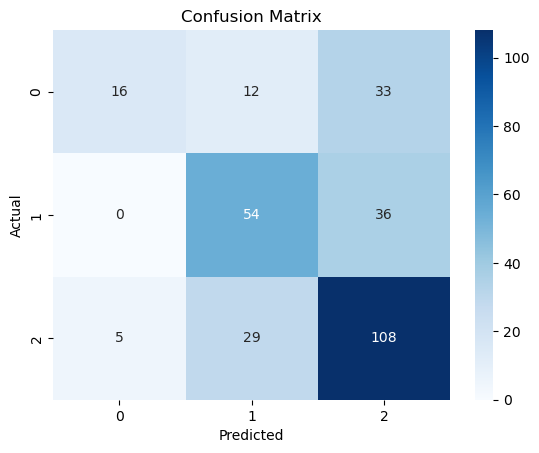

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [23]:
import pandas as pd

importance = model.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feat_imp.head(10))

     Feature  Importance
17   AXCHEST    0.057520
24  AXDPMOOD    0.039471
23  AXINSOMN    0.038496
14  AXBREATH    0.036774
1        Age    0.036501
6   AXABDOMN    0.036402
11  AXVISION    0.035836
10  AXDROWSY    0.034609
22    AXRASH    0.034553
25  AXCRYING    0.034254


Dataset Shape: (1464, 51)
  Image Data ID     Subject Group Sex  Age Visit Modality  \
0       I112538  941_S_1311   MCI   M   70   m12      MRI   
1        I97341  941_S_1311   MCI   M   70   m06      MRI   
2        I75150  941_S_1202    CN   M   78   m06      MRI   
3       I105437  941_S_1202    CN   M   79   m12      MRI   
4       I108336  941_S_1197    CN   F   84   m12      MRI   

                                  Description       Type   Acq Date  ...  \
0    MPR; GradWarp; B1 Correction; N3; Scaled  Processed  6/01/2008  ...   
1  MPR-R; GradWarp; B1 Correction; N3; Scaled  Processed  9/27/2007  ...   
2    MPR; GradWarp; B1 Correction; N3; Scaled  Processed  8/24/2007  ...   
3    MPR; GradWarp; B1 Correction; N3; Scaled  Processed  2/28/2008  ...   
4    MPR; GradWarp; B1 Correction; N3; Scaled  Processed  5/21/2008  ...   

  AXCRYING AXELMOOD AXWANDER AXFALL  AXOTHER    ID SITEID    USERDATE  \
0        1        1        1      1      1.0  4150    127  2008-05-05   
1   

d:\Anaconda\envs\py310\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


After SMOTE: [568 568 568]
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20, 'bootstrap': False}
Best CV Score: 0.6379213386234259

Classification Report:

              precision    recall  f1-score   support

           0       0.51      0.57      0.54        61
           1       0.56      0.73      0.64        90
           2       0.74      0.56      0.63       142

    accuracy                           0.61       293
   macro avg       0.60      0.62      0.60       293
weighted avg       0.64      0.61      0.62       293


Confusion Matrix:

[[35 10 16]
 [12 66 12]
 [22 41 79]]


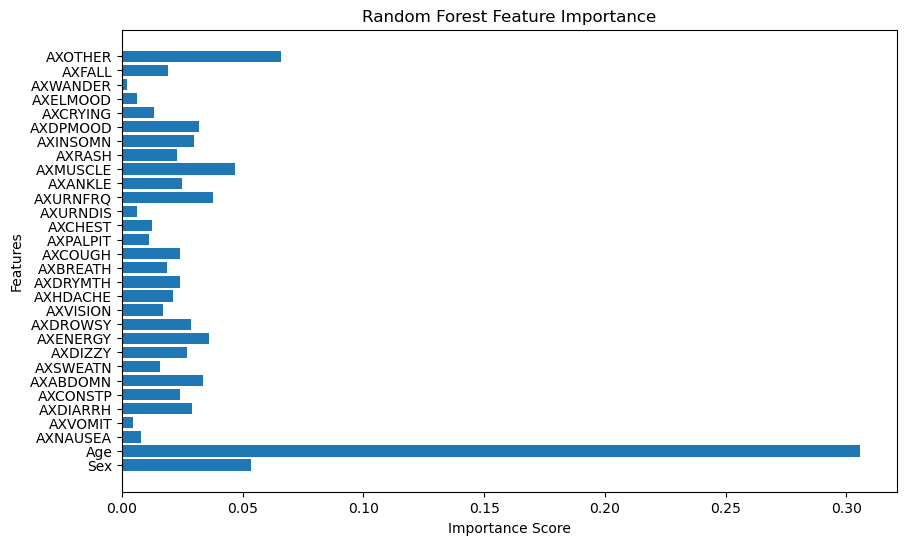


Random Forest model saved successfully!


In [25]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

import joblib
import matplotlib.pyplot as plt

# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv("ADNI1_Merged_MRI_Metadata.csv")

print("Dataset Shape:", df.shape)
print(df.head())
# Drop useless columns
drop_cols = [
    'Image Data ID', 'Subject', 'Visit', 'Modality', 'Description',
    'Type', 'Acq Date', 'Format', 'Downloaded', 'PHASE',
    'PTID', 'RID', 'VISCODE', 'VISCODE2', 'VISDATE',
    'ID', 'SITEID', 'USERDATE', 'USERDATE2', 'update_stamp'
]

df = df.drop(columns=[col for col in drop_cols if col in df.columns])
df['Sex'] = df['Sex'].map({'M': 0, 'F': 1})
# =========================
# 3. ENCODE TARGET
# =========================
le = LabelEncoder()
df['Group'] = le.fit_transform(df['Group'])

# =========================
# 4. SPLIT FEATURES & LABEL
# =========================
X = df.drop('Group', axis=1)
y = df['Group']

# =========================
# 5. TRAIN-TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# 6. HANDLE CLASS IMBALANCE
# =========================
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:", np.bincount(y_train))

# =========================
# 7. DEFINE MODEL
# =========================
rf = RandomForestClassifier(random_state=42)

# =========================
# 8. HYPERPARAMETER SPACE
# =========================
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

# =========================
# 9. CROSS-VALIDATION
# =========================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# =========================
# 10. RANDOM SEARCH
# =========================
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,
    scoring='accuracy',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# =========================
# 11. TRAIN MODEL
# =========================
random_search.fit(X_train, y_train)

print("\nBest Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

# =========================
# 12. BEST MODEL
# =========================
best_rf = random_search.best_estimator_

# =========================
# 13. PREDICTIONS
# =========================
y_pred = best_rf.predict(X_test)

# =========================
# 14. EVALUATION
# =========================
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

# =========================
# 15. FEATURE IMPORTANCE
# =========================
importance = best_rf.feature_importances_

plt.figure(figsize=(10, 6))
plt.barh(X.columns, importance)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

# =========================
# 16. SAVE MODEL
# =========================
joblib.dump(best_rf, "tuned_random_forest.pkl")

print("\nRandom Forest model saved successfully!")

Dataset Shape: (1464, 51)
  Image Data ID     Subject Group Sex  Age Visit Modality  \
0       I112538  941_S_1311   MCI   M   70   m12      MRI   
1        I97341  941_S_1311   MCI   M   70   m06      MRI   
2        I75150  941_S_1202    CN   M   78   m06      MRI   
3       I105437  941_S_1202    CN   M   79   m12      MRI   
4       I108336  941_S_1197    CN   F   84   m12      MRI   

                                  Description       Type   Acq Date  ...  \
0    MPR; GradWarp; B1 Correction; N3; Scaled  Processed  6/01/2008  ...   
1  MPR-R; GradWarp; B1 Correction; N3; Scaled  Processed  9/27/2007  ...   
2    MPR; GradWarp; B1 Correction; N3; Scaled  Processed  8/24/2007  ...   
3    MPR; GradWarp; B1 Correction; N3; Scaled  Processed  2/28/2008  ...   
4    MPR; GradWarp; B1 Correction; N3; Scaled  Processed  5/21/2008  ...   

  AXCRYING AXELMOOD AXWANDER AXFALL  AXOTHER    ID SITEID    USERDATE  \
0        1        1        1      1      1.0  4150    127  2008-05-05   
1   

d:\Anaconda\envs\py310\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(



Best Parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20, 'bootstrap': False}
Best CV Score: 0.6819182335690874

Classification Report:

              precision    recall  f1-score   support

           0       0.47      0.36      0.41        61
           1       0.89      0.09      0.16        90
           2       0.52      0.87      0.65       142

    accuracy                           0.52       293
   macro avg       0.63      0.44      0.41       293
weighted avg       0.62      0.52      0.45       293


Confusion Matrix:

[[ 22   0  39]
 [  7   8  75]
 [ 18   1 123]]


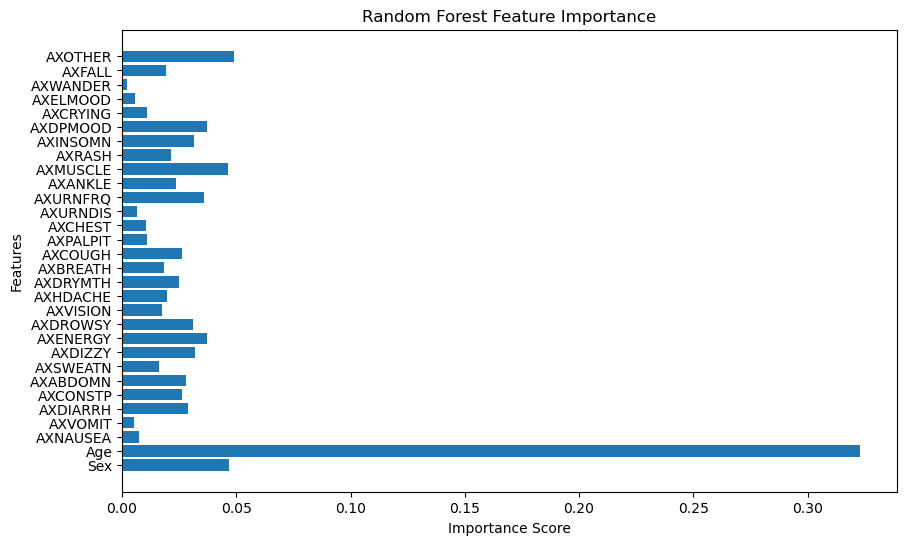


Random Forest model saved successfully!


In [26]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

import joblib
import matplotlib.pyplot as plt

# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv("ADNI1_Merged_MRI_Metadata.csv")

print("Dataset Shape:", df.shape)
print(df.head())

# =========================
# 2a. DROP UNUSED COLUMNS
# =========================
drop_cols = [
    'Image Data ID', 'Subject', 'Visit', 'Modality', 'Description',
    'Type', 'Acq Date', 'Format', 'Downloaded', 'PHASE',
    'PTID', 'RID', 'VISCODE', 'VISCODE2', 'VISDATE',
    'ID', 'SITEID', 'USERDATE', 'USERDATE2', 'update_stamp'
]
df = df.drop(columns=[col for col in drop_cols if col in df.columns])

# =========================
# 2b. ENCODE SEX
# =========================
df['Sex'] = df['Sex'].map({'M': 0, 'F': 1})

# =========================
# 3. ENCODE TARGET
# =========================
le = LabelEncoder()
df['Group'] = le.fit_transform(df['Group'])

# =========================
# 4. SPLIT FEATURES & LABEL
# =========================
X = df.drop('Group', axis=1)
y = df['Group']

# =========================
# 4a. SCALE AGE ONLY
# =========================
scaler = StandardScaler()
if 'Age' in X.columns:
    X['Age'] = scaler.fit_transform(X[['Age']])

# =========================
# 5. TRAIN-TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 5a. SCALE AGE IN TEST DATA
# =========================
if 'Age' in X_test.columns:
    X_test['Age'] = scaler.transform(X_test[['Age']])

# =========================
# 6. HANDLE CLASS IMBALANCE (SMOTE)
# =========================
smote = SMOTE(random_state=42, k_neighbors=2)  # k_neighbors reduced for small classes
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:", np.bincount(y_train))

# =========================
# 7. DEFINE RANDOM FOREST MODEL
# =========================
rf = RandomForestClassifier(random_state=42)

# =========================
# 8. HYPERPARAMETER SPACE
# =========================
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

# =========================
# 9. CROSS-VALIDATION
# =========================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# =========================
# 10. RANDOMIZED SEARCH
# =========================
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,
    scoring='accuracy',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# =========================
# 11. TRAIN MODEL
# =========================
random_search.fit(X_train, y_train)

print("\nBest Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

# =========================
# 12. BEST MODEL
# =========================
best_rf = random_search.best_estimator_

# =========================
# 13. PREDICTIONS
# =========================
y_pred = best_rf.predict(X_test)

# =========================
# 14. EVALUATION
# =========================
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

# =========================
# 15. FEATURE IMPORTANCE
# =========================
importance = best_rf.feature_importances_

plt.figure(figsize=(10, 6))
plt.barh(X.columns, importance)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

# =========================
# 16. SAVE MODEL
# =========================
joblib.dump(best_rf, "tuned_random_forest.pkl")

print("\nRandom Forest model saved successfully!")

Dataset Shape: (1464, 51)
  Image Data ID     Subject Group Sex  Age Visit Modality  \
0       I112538  941_S_1311   MCI   M   70   m12      MRI   
1        I97341  941_S_1311   MCI   M   70   m06      MRI   
2        I75150  941_S_1202    CN   M   78   m06      MRI   
3       I105437  941_S_1202    CN   M   79   m12      MRI   
4       I108336  941_S_1197    CN   F   84   m12      MRI   

                                  Description       Type   Acq Date  ...  \
0    MPR; GradWarp; B1 Correction; N3; Scaled  Processed  6/01/2008  ...   
1  MPR-R; GradWarp; B1 Correction; N3; Scaled  Processed  9/27/2007  ...   
2    MPR; GradWarp; B1 Correction; N3; Scaled  Processed  8/24/2007  ...   
3    MPR; GradWarp; B1 Correction; N3; Scaled  Processed  2/28/2008  ...   
4    MPR; GradWarp; B1 Correction; N3; Scaled  Processed  5/21/2008  ...   

  AXCRYING AXELMOOD AXWANDER AXFALL  AXOTHER    ID SITEID    USERDATE  \
0        1        1        1      1      1.0  4150    127  2008-05-05   
1   

d:\Anaconda\envs\py310\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
d:\Anaconda\envs\py310\lib\site-packages\xgboost\training.py:200: UserWarning: [00:00:22] WARNING: C:\Users\task_177465309458303\croot\xgboost-split_1774653200626\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best Parameters: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 9, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.7}
Best CV Score: 0.6537467655683975

Classification Report:

              precision    recall  f1-score   support

           0       0.51      0.52      0.52        61
           1       0.58      0.72      0.64        90
           2       0.69      0.57      0.62       142

    accuracy                           0.61       293
   macro avg       0.59      0.61      0.59       293
weighted avg       0.62      0.61      0.61       293


Confusion Matrix:

[[32  8 21]
 [ 9 65 16]
 [22 39 81]]


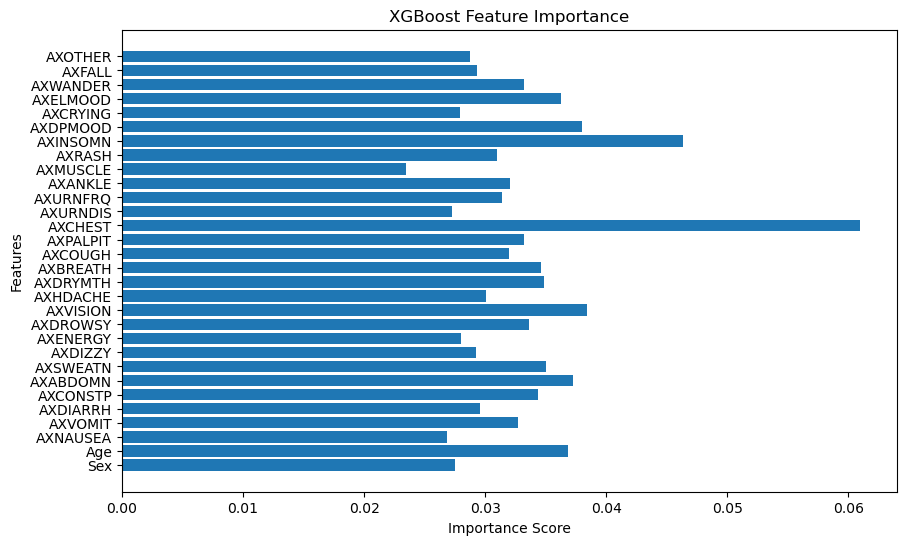


XGBoost model saved successfully!


In [28]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

import joblib
import matplotlib.pyplot as plt

# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv("ADNI1_Merged_MRI_Metadata.csv")

print("Dataset Shape:", df.shape)
print(df.head())

# =========================
# 2a. DROP UNUSED COLUMNS
# =========================
drop_cols = [
    'Image Data ID', 'Subject', 'Visit', 'Modality', 'Description',
    'Type', 'Acq Date', 'Format', 'Downloaded', 'PHASE',
    'PTID', 'RID', 'VISCODE', 'VISCODE2', 'VISDATE',
    'ID', 'SITEID', 'USERDATE', 'USERDATE2', 'update_stamp'
]
df = df.drop(columns=[col for col in drop_cols if col in df.columns])

# =========================
# 2b. ENCODE SEX
# =========================
df['Sex'] = df['Sex'].map({'M': 0, 'F': 1})

# =========================
# 3. ENCODE TARGET
# =========================
le = LabelEncoder()
df['Group'] = le.fit_transform(df['Group'])

# =========================
# 4. SPLIT FEATURES & LABEL
# =========================
X = df.drop('Group', axis=1)
y = df['Group']

# =========================
# 4a. SCALE AGE ONLY
# =========================
scaler = StandardScaler()
if 'Age' in X.columns:
    X['Age'] = scaler.fit_transform(X[['Age']])

# =========================
# 5. TRAIN-TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 6. HANDLE CLASS IMBALANCE (SMOTE)
# =========================
smote = SMOTE(random_state=42, k_neighbors=2)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:", np.bincount(y_train))

# =========================
# 7. DEFINE XGBOOST MODEL
# =========================
xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=len(np.unique(y)),
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42
)

# =========================
# 8. HYPERPARAMETER SPACE
# =========================
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3],
    'min_child_weight': [1, 3, 5]
}

# =========================
# 9. CROSS-VALIDATION
# =========================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# =========================
# 10. RANDOMIZED SEARCH
# =========================
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,
    scoring='accuracy',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# =========================
# 11. TRAIN MODEL
# =========================
random_search.fit(X_train, y_train)

print("\nBest Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

# =========================
# 12. BEST MODEL
# =========================
best_xgb = random_search.best_estimator_

# =========================
# 13. PREDICTIONS
# =========================
y_pred = best_xgb.predict(X_test)

# =========================
# 14. EVALUATION
# =========================
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

# =========================
# 15. FEATURE IMPORTANCE
# =========================
importance = best_xgb.feature_importances_

plt.figure(figsize=(10, 6))
plt.barh(X.columns, importance)
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

# =========================
# 16. SAVE MODEL
# =========================
joblib.dump(best_xgb, "tuned_xgboost_model.pkl")

print("\nXGBoost model saved successfully!")

d:\Anaconda\envs\py310\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
d:\Anaconda\envs\py310\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
d:\Anaconda\envs\py310\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


After SMOTEENN: [303 197 105]
Fitting 5 folds for each of 30 candidates, totalling 150 fits
RF Best Score: 0.8413223140495868
RF Best Params: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20, 'bootstrap': True}
Fitting 5 folds for each of 30 candidates, totalling 150 fits


d:\Anaconda\envs\py310\lib\site-packages\xgboost\training.py:200: UserWarning: [00:27:22] WARNING: C:\Users\task_177465309458303\croot\xgboost-split_1774653200626\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGB Best Score: 0.8132231404958677
XGB Best Params: {'subsample': 0.7, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.7}
Epoch 1/200
16/16 [==============================] - 1s 24ms/step - loss: 1.0058 - accuracy: 0.4938 - val_loss: 14.0507 - val_accuracy: 0.0000e+00
Epoch 2/200
16/16 [==============================] - 0s 11ms/step - loss: 0.7047 - accuracy: 0.6467 - val_loss: 18.6812 - val_accuracy: 0.0000e+00
Epoch 3/200
16/16 [==============================] - 0s 10ms/step - loss: 0.6276 - accuracy: 0.6880 - val_loss: 19.7027 - val_accuracy: 0.0000e+00
Epoch 4/200
16/16 [==============================] - 0s 10ms/step - loss: 0.5989 - accuracy: 0.7025 - val_loss: 17.3057 - val_accuracy: 0.0000e+00
Epoch 5/200
16/16 [==============================] - 0s 11ms/step - loss: 0.5888 - accuracy: 0.7045 - val_loss: 16.6069 - val_accuracy: 0.0000e+00
Epoch 6/200
16/16 [==============================] - 0s 13ms/step - loss: 0

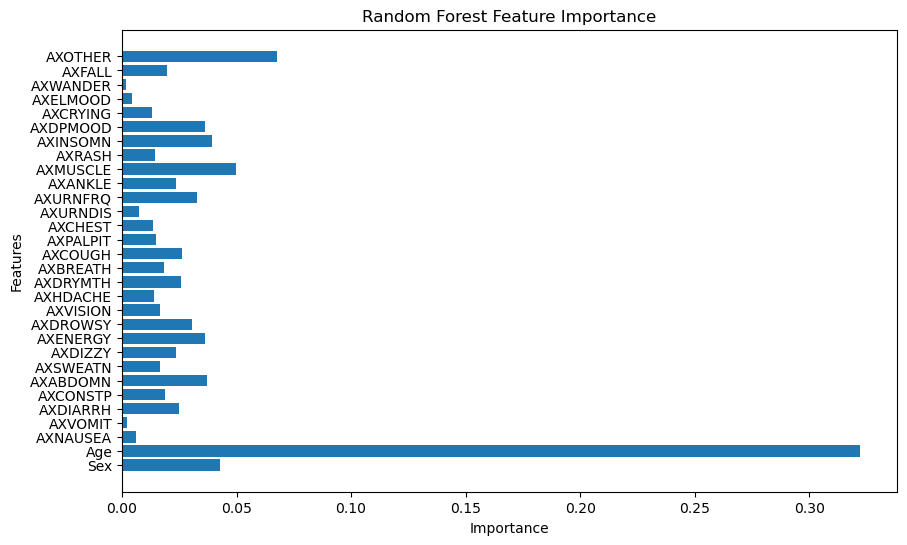

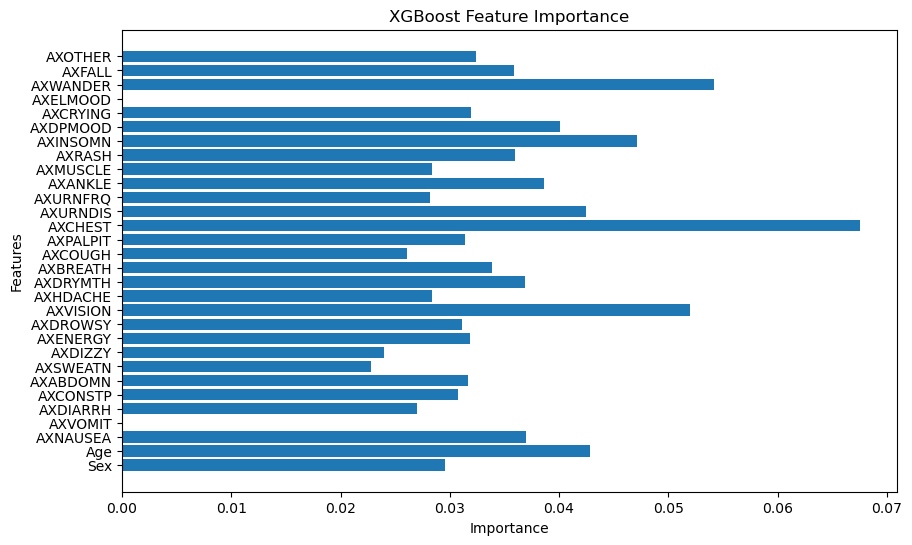


All models saved successfully!


In [3]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

from xgboost import XGBClassifier
from imblearn.combine import SMOTEENN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

import joblib

# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv("ADNI1_Merged_MRI_Metadata.csv")

# Drop unnecessary columns
drop_cols = [
    'Image Data ID', 'Subject', 'Visit', 'Modality', 'Description',
    'Type', 'Acq Date', 'Format', 'Downloaded', 'PHASE',
    'PTID', 'RID', 'VISCODE', 'VISCODE2', 'VISDATE',
    'ID', 'SITEID', 'USERDATE', 'USERDATE2', 'update_stamp'
]
df = df.drop(columns=[col for col in drop_cols if col in df.columns])

# Encode Sex
df['Sex'] = df['Sex'].map({'M':0, 'F':1})

# Encode target
le = LabelEncoder()
df['Group'] = le.fit_transform(df['Group'])

# =========================
# 3. SPLIT FEATURES & LABEL
# =========================
X = df.drop('Group', axis=1)
y = df['Group']



# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
if 'Age' in X_test.columns:
    X_test['Age'] = scaler.transform(X_test[['Age']])

# =========================
# 4. HANDLE CLASS IMBALANCE
# =========================
sm = SMOTEENN(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)
print("After SMOTEENN:", np.bincount(y_train))

# =========================
# 5. RANDOM FOREST
# =========================
rf = RandomForestClassifier(random_state=42)

rf_param = {
    'n_estimators':[200, 300, 500],
    'max_depth':[None, 10, 20],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4],
    'max_features':['sqrt', 'log2'],
    'bootstrap':[True, False]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_search = RandomizedSearchCV(rf, rf_param, n_iter=30, scoring='accuracy',
                               cv=cv, verbose=1, n_jobs=-1, random_state=42)
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_
print("RF Best Score:", rf_search.best_score_)
print("RF Best Params:", rf_search.best_params_)

# =========================
# 6. XGBOOST
# =========================
xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=len(np.unique(y)),
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42
)

xgb_param = {
    'n_estimators':[200,300,500],
    'max_depth':[3,5,7],
    'learning_rate':[0.01,0.05,0.1],
    'subsample':[0.7,0.8,1.0],
    'colsample_bytree':[0.7,0.8,1.0],
    'gamma':[0,0.1,0.3],
    'min_child_weight':[1,3,5]
}

xgb_search = RandomizedSearchCV(xgb, xgb_param, n_iter=30, scoring='accuracy',
                                cv=cv, verbose=1, n_jobs=-1, random_state=42)
xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_
print("XGB Best Score:", xgb_search.best_score_)
print("XGB Best Params:", xgb_search.best_params_)

# =========================
# 7. MLP
# =========================
from tensorflow.keras.utils import to_categorical

num_classes = len(np.unique(y))
y_train_cat = y_train
y_test_cat = y_test

mlp = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

mlp.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

mlp.fit(X_train, y_train_cat, validation_split=0.2,
        epochs=200, batch_size=32, callbacks=[es], verbose=1)

# =========================
# 8. ENSEMBLE
# =========================
ensemble = VotingClassifier(
    estimators=[('rf', best_rf), ('xgb', best_xgb)],
    voting='soft', n_jobs=-1
)
ensemble.fit(X_train, y_train)

# =========================
# 9. EVALUATION
# =========================
models = {'Random Forest': best_rf, 'XGBoost': best_xgb, 'Ensemble': ensemble}

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))

# =========================
# 10. FEATURE IMPORTANCE (RF + XGB)
# =========================
for name, model in zip(['Random Forest','XGBoost'], [best_rf,best_xgb]):
    importance = model.feature_importances_
    plt.figure(figsize=(10,6))
    plt.barh(X.columns, importance)
    plt.title(f"{name} Feature Importance")
    plt.xlabel("Importance")
    plt.ylabel("Features")
    plt.show()

# =========================
# 11. SAVE MODELS
# =========================
joblib.dump(best_rf, "rf_model.pkl")
joblib.dump(best_xgb, "xgb_model.pkl")
joblib.dump(ensemble, "ensemble_model.pkl")
mlp.save("mlp_model.h5")

print("\nAll models saved successfully!")

In [4]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import joblib

# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv("ADNI1_Merged_MRI_Metadata.csv")

# Drop unnecessary columns
drop_cols = [
    'Image Data ID', 'Subject', 'Visit', 'Modality', 'Description',
    'Type', 'Acq Date', 'Format', 'Downloaded', 'PHASE',
    'PTID', 'RID', 'VISCODE', 'VISCODE2', 'VISDATE',
    'ID', 'SITEID', 'USERDATE', 'USERDATE2', 'update_stamp'
]
df = df.drop(columns=[col for col in drop_cols if col in df.columns])

# Encode Sex
df['Sex'] = df['Sex'].map({'M':0, 'F':1})

# Encode target
le = LabelEncoder()
df['Group'] = le.fit_transform(df['Group'])

# =========================
# 3. SPLIT FEATURES & LABEL
# =========================
X = df.drop('Group', axis=1)
y = df['Group']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# =========================
# 4. SCALE AGE ONLY (NO LEAKAGE)
# =========================
scaler = StandardScaler()
if 'Age' in X.columns:
    X_train['Age'] = scaler.fit_transform(X_train[['Age']])
    X_test['Age'] = scaler.transform(X_test[['Age']])

# =========================
# 5. HANDLE CLASS IMBALANCE (SMOTE)
# =========================
from collections import Counter
print("Before SMOTE:", Counter(y_train))

smote = SMOTE(random_state=42, k_neighbors=3)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:", Counter(y_train))

# =========================
# 6. RANDOM FOREST
# =========================
rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

rf_param = {
    'n_estimators':[200,300,500],
    'max_depth':[None,10,20],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_search = RandomizedSearchCV(
    rf, rf_param, n_iter=20,
    scoring='f1_weighted',
    cv=cv, n_jobs=-1, verbose=1
)
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

# =========================
# 7. XGBOOST
# =========================
xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=len(np.unique(y)),
    eval_metric='mlogloss',
    random_state=42
)

xgb_param = {
    'n_estimators':[200,300],
    'max_depth':[3,5,7],
    'learning_rate':[0.01,0.05,0.1],
    'subsample':[0.8,1.0],
    'colsample_bytree':[0.8,1.0]
}

xgb_search = RandomizedSearchCV(
    xgb, xgb_param, n_iter=20,
    scoring='f1_weighted',
    cv=cv, n_jobs=-1, verbose=1
)
xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_

# =========================
# 8. MLP (FIXED)
# =========================
num_classes = len(np.unique(y))

mlp = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

mlp.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

mlp.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# =========================
# 9. ENSEMBLE
# =========================
ensemble = VotingClassifier(
    estimators=[('rf', best_rf), ('xgb', best_xgb)],
    voting='soft'
)
ensemble.fit(X_train, y_train)

# =========================
# 10. EVALUATION FUNCTION
# =========================
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    print(f"\n{name} Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))
    print("\nConfusion Matrix:\n")
    print(confusion_matrix(y_test, y_pred))

# =========================
# 11. EVALUATE MODELS
# =========================
evaluate_model("Random Forest", best_rf, X_test, y_test)
evaluate_model("XGBoost", best_xgb, X_test, y_test)
evaluate_model("Ensemble", ensemble, X_test, y_test)

# MLP evaluation
mlp_pred = np.argmax(mlp.predict(X_test), axis=1)
evaluate_model("MLP", mlp, X_test, y_test)

# =========================
# 12. SAVE MODELS
# =========================
joblib.dump(best_rf, "rf_model.pkl")
joblib.dump(best_xgb, "xgb_model.pkl")
joblib.dump(ensemble, "ensemble_model.pkl")
mlp.save("mlp_model.h5")

print("\nAll models saved successfully!")

Before SMOTE: Counter({2: 568, 1: 361, 0: 242})
After SMOTE: Counter({1: 568, 0: 568, 2: 568})
Fitting 5 folds for each of 20 candidates, totalling 100 fits


d:\Anaconda\envs\py310\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Epoch 1/50
43/43 [==============================] - 1s 11ms/step - loss: 1.1362 - accuracy: 0.3551 - val_loss: 1.2812 - val_accuracy: 0.0264
Epoch 2/50
43/43 [==============================] - 0s 7ms/step - loss: 1.0828 - accuracy: 0.4138 - val_loss: 1.2913 - val_accuracy: 0.0059
Epoch 3/50
43/43 [==============================] - 0s 7ms/step - loss: 1.0775 - accuracy: 0.4138 - val_loss: 1.1387 - val_accuracy: 0.2639
Epoch 4/50
43/43 [==============================] - 0s 7ms/step - loss: 1.0686 - accuracy: 0.4160 - val_loss: 1.1459 - val_accuracy: 0.2229
Epoch 5/50
43/43 [==============================] - 0s 7ms/step - loss: 1.0641 - accuracy: 0.4175 - val_loss: 1.1905 - val_accuracy: 0.1320
Epoch 6/50
43/43 [==============================] - 0s 7ms/step - loss: 1.0477 - accuracy: 0.4292 - val_loss: 1.1758 - val_accuracy: 0.2287
Epoch 7/50
43/43 [==============================] - 0s 7ms/step - loss: 1.0461 - accuracy: 0.4255

ValueError: Classification metrics can't handle a mix of multiclass and continuous-multioutput targets

In [5]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

import joblib
from collections import Counter

# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv("ADNI1_Merged_MRI_Metadata.csv")

# Drop unnecessary columns
drop_cols = [
    'Image Data ID', 'Subject', 'Visit', 'Modality', 'Description',
    'Type', 'Acq Date', 'Format', 'Downloaded', 'PHASE',
    'PTID', 'RID', 'VISCODE', 'VISCODE2', 'VISDATE',
    'ID', 'SITEID', 'USERDATE', 'USERDATE2', 'update_stamp'
]
df = df.drop(columns=[col for col in drop_cols if col in df.columns])

# Encode Sex
df['Sex'] = df['Sex'].map({'M': 0, 'F': 1})

# Encode target
le = LabelEncoder()
df['Group'] = le.fit_transform(df['Group'])

# =========================
# 3. SPLIT FEATURES & LABEL
# =========================
X = df.drop('Group', axis=1)
y = df['Group']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# =========================
# 4. SCALE AGE ONLY (NO DATA LEAKAGE)
# =========================
scaler = StandardScaler()

if 'Age' in X.columns:
    X_train['Age'] = scaler.fit_transform(X_train[['Age']])
    X_test['Age'] = scaler.transform(X_test[['Age']])

# =========================
# 5. HANDLE CLASS IMBALANCE (SMOTE)
# =========================
print("Before SMOTE:", Counter(y_train))

smote = SMOTE(random_state=42, k_neighbors=3)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:", Counter(y_train))

# =========================
# 6. RANDOM FOREST (TUNING)
# =========================
rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

rf_param = {
    'n_estimators': [200, 300, 500],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_search = RandomizedSearchCV(
    rf,
    rf_param,
    n_iter=20,
    scoring='f1_weighted',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_

print("\nRF Best Params:", rf_search.best_params_)

# =========================
# 7. XGBOOST (TUNING)
# =========================
xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=len(np.unique(y)),
    eval_metric='mlogloss',
    random_state=42
)

xgb_param = {
    'n_estimators': [200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    xgb,
    xgb_param,
    n_iter=20,
    scoring='f1_weighted',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_

print("\nXGB Best Params:", xgb_search.best_params_)

# =========================
# 8. ENSEMBLE (RF + XGB)
# =========================
ensemble = VotingClassifier(
    estimators=[
        ('rf', best_rf),
        ('xgb', best_xgb)
    ],
    voting='soft',
    weights=[1, 2]   # give more weight to XGBoost
)

ensemble.fit(X_train, y_train)

# =========================
# 9. EVALUATION FUNCTION
# =========================
def evaluate_model(name, model):
    y_pred = model.predict(X_test)

    print("\n" + "="*40)
    print(f"{name} RESULTS")
    print("="*40)

    print("Accuracy:", accuracy_score(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

# =========================
# 10. EVALUATE MODELS
# =========================
evaluate_model("Random Forest", best_rf)
evaluate_model("XGBoost", best_xgb)
evaluate_model("Ensemble (RF + XGB)", ensemble)

# =========================
# 11. SAVE MODELS
# =========================
joblib.dump(best_rf, "rf_model.pkl")
joblib.dump(best_xgb, "xgb_model.pkl")
joblib.dump(ensemble, "ensemble_model.pkl")

print("\nAll models saved successfully!")

Before SMOTE: Counter({2: 568, 1: 361, 0: 242})
After SMOTE: Counter({1: 568, 0: 568, 2: 568})
Fitting 5 folds for each of 20 candidates, totalling 100 fits


d:\Anaconda\envs\py310\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(



RF Best Params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}
Fitting 5 folds for each of 20 candidates, totalling 100 fits

XGB Best Params: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.8}

Random Forest RESULTS
Accuracy: 0.6006825938566553

Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.48      0.49        61
           1       0.55      0.76      0.64        90
           2       0.70      0.56      0.62       142

    accuracy                           0.60       293
   macro avg       0.59      0.60      0.58       293
weighted avg       0.61      0.60      0.60       293


Confusion Matrix:
[[29 12 20]
 [ 8 68 14]
 [20 43 79]]

XGBoost RESULTS
Accuracy: 0.5665529010238908

Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.39      0.41        61
           1       0.5

In [7]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

import joblib
from collections import Counter

# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv("ADNI1_Merged_MRI_Metadata.csv")

# Drop unnecessary columns
drop_cols = [
    'Image Data ID', 'Subject', 'Visit', 'Modality', 'Description',
    'Type', 'Acq Date', 'Format', 'Downloaded', 'PHASE',
    'PTID', 'RID', 'VISCODE', 'VISCODE2', 'VISDATE',
    'ID', 'SITEID', 'USERDATE', 'USERDATE2', 'update_stamp'
]
df = df.drop(columns=[col for col in drop_cols if col in df.columns])

# Encode Sex
df['Sex'] = df['Sex'].map({'M': 0, 'F': 1})

# Encode target
le = LabelEncoder()
df['Group'] = le.fit_transform(df['Group'])

# =========================
# 3. FEATURE ENGINEERING
# =========================
def add_features(df):

    gi_cols = ['AXNAUSEA', 'AXVOMIT', 'AXDIARRH', 'AXCONSTP', 'AXABDOMN']
    df['GI_score'] = df[gi_cols].sum(axis=1)

    neuro_cols = ['AXDIZZY', 'AXFALL', 'AXWANDER']
    df['Neuro_score'] = df[neuro_cols].sum(axis=1)

    mood_cols = ['AXDPMOOD', 'AXCRYING', 'AXELMOOD', 'AXINSOMN']
    df['Mood_score'] = df[mood_cols].sum(axis=1)

    pain_cols = ['AXMUSCLE', 'AXANKLE']
    df['Pain_score'] = df[pain_cols].sum(axis=1)

    symptom_cols = [col for col in df.columns if col.startswith('AX')]
    df['Total_symptoms'] = df[symptom_cols].sum(axis=1)

    df['Age_group'] = pd.cut(df['Age'],
                            bins=[0, 65, 75, 85, 100],
                            labels=[0, 1, 2, 3]).astype(int)

    return df

# =========================
# 4. SPLIT FEATURES & LABEL
# =========================
X = df.drop('Group', axis=1)
y = df['Group']

# Apply feature engineering
X = add_features(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


# 6. HANDLE CLASS IMBALANCE
# =========================
print("Before SMOTE:", Counter(y_train))

smote = SMOTE(random_state=42, k_neighbors=3)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:", Counter(y_train))

# =========================
# 7. RANDOM FOREST
# =========================
rf = RandomForestClassifier(class_weight='balanced', random_state=42)

rf_param = {
    'n_estimators': [200, 300, 500],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_search = RandomizedSearchCV(
    rf, rf_param,
    n_iter=15,
    scoring='f1_weighted',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

print("\nRF Best Params:", rf_search.best_params_)

# =========================
# 8. XGBOOST
# =========================
xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=len(np.unique(y)),
    eval_metric='mlogloss',
    random_state=42
)

xgb_param = {
    'n_estimators': [300, 500],
    'max_depth': [5, 7, 9],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.7, 0.8],
    'gamma': [0, 0.1]
}

xgb_search = RandomizedSearchCV(
    xgb, xgb_param,
    n_iter=15,
    scoring='f1_weighted',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_

print("\nXGB Best Params:", xgb_search.best_params_)

# =========================
# 9. ENSEMBLE (RF + XGB)
# =========================
ensemble = VotingClassifier(
    estimators=[('rf', best_rf), ('xgb', best_xgb)],
    voting='soft',
    weights=[1, 2]
)

ensemble.fit(X_train, y_train)

# =========================
# 10. EVALUATION
# =========================
def evaluate_model(name, model):
    y_pred = model.predict(X_test)

    print("\n" + "="*40)
    print(f"{name} RESULTS")
    print("="*40)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

# Evaluate
evaluate_model("Random Forest", best_rf)
evaluate_model("XGBoost", best_xgb)
evaluate_model("Ensemble (RF + XGB)", ensemble)

# =========================
# 11. SAVE MODELS
# =========================
joblib.dump(best_rf, "rf_model.pkl")
joblib.dump(best_xgb, "xgb_model.pkl")
joblib.dump(ensemble, "ensemble_model.pkl")

print("\nAll models saved successfully!")

Before SMOTE: Counter({2: 568, 1: 361, 0: 242})
After SMOTE: Counter({1: 568, 0: 568, 2: 568})
Fitting 5 folds for each of 15 candidates, totalling 75 fits


d:\Anaconda\envs\py310\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(



RF Best Params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}
Fitting 5 folds for each of 15 candidates, totalling 75 fits

XGB Best Params: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 9, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.7}

Random Forest RESULTS
Accuracy: 0.5733788395904437

Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.51      0.50        61
           1       0.54      0.59      0.56        90
           2       0.64      0.59      0.62       142

    accuracy                           0.57       293
   macro avg       0.56      0.56      0.56       293
weighted avg       0.58      0.57      0.57       293


Confusion Matrix:
[[31  8 22]
 [12 53 25]
 [21 37 84]]

XGBoost RESULTS
Accuracy: 0.5802047781569966

Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.46      0.46        61
        

In [8]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

import joblib
from collections import Counter

# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv("ADNI1_Merged_MRI_Metadata.csv")

# Drop unnecessary columns
drop_cols = [
    'Image Data ID', 'Subject', 'Visit', 'Modality', 'Description',
    'Type', 'Acq Date', 'Format', 'Downloaded', 'PHASE',
    'PTID', 'RID', 'VISCODE', 'VISCODE2', 'VISDATE',
    'ID', 'SITEID', 'USERDATE', 'USERDATE2', 'update_stamp'
]
df = df.drop(columns=[col for col in drop_cols if col in df.columns])

# Encode Sex
df['Sex'] = df['Sex'].map({'M': 0, 'F': 1})

# Encode target
le = LabelEncoder()
df['Group'] = le.fit_transform(df['Group'])

# =========================
# 3. FEATURE ENGINEERING
# =========================
def add_features(df):

    gi_cols = ['AXNAUSEA', 'AXVOMIT', 'AXDIARRH', 'AXCONSTP', 'AXABDOMN']
    df['GI_score'] = df[gi_cols].sum(axis=1)

    neuro_cols = ['AXDIZZY', 'AXFALL', 'AXWANDER']
    df['Neuro_score'] = df[neuro_cols].sum(axis=1)

    mood_cols = ['AXDPMOOD', 'AXCRYING', 'AXELMOOD', 'AXINSOMN']
    df['Mood_score'] = df[mood_cols].sum(axis=1)

    pain_cols = ['AXMUSCLE', 'AXANKLE']
    df['Pain_score'] = df[pain_cols].sum(axis=1)

    symptom_cols = [col for col in df.columns if col.startswith('AX')]
    df['Total_symptoms'] = df[symptom_cols].sum(axis=1)

    df['Age_group'] = pd.cut(df['Age'],
                            bins=[0, 65, 75, 85, 100],
                            labels=[0, 1, 2, 3]).astype(int)

    return df

# =========================
# 4. SPLIT FEATURES & LABEL
# =========================
X = df.drop('Group', axis=1)
y = df['Group']

# Apply feature engineering
X = add_features(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# =========================
# 5. SCALE AGE ONLY (NO LEAKAGE)
# =========================
scaler = StandardScaler()

if 'Age' in X.columns:
    X_train['Age'] = scaler.fit_transform(X_train[['Age']])
    X_test['Age'] = scaler.transform(X_test[['Age']])

# =========================
# 6. HANDLE CLASS IMBALANCE
# =========================
print("Before SMOTE:", Counter(y_train))

smote = SMOTE(random_state=42, k_neighbors=3)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:", Counter(y_train))

# =========================
# 7. RANDOM FOREST
# =========================
rf = RandomForestClassifier(class_weight='balanced', random_state=42)

rf_param = {
    'n_estimators': [200, 300, 500],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_search = RandomizedSearchCV(
    rf, rf_param,
    n_iter=15,
    scoring='f1_weighted',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

print("\nRF Best Params:", rf_search.best_params_)

# =========================
# 8. XGBOOST
# =========================
xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=len(np.unique(y)),
    eval_metric='mlogloss',
    random_state=42
)

xgb_param = {
    'n_estimators': [300, 500],
    'max_depth': [5, 7, 9],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.7, 0.8],
    'gamma': [0, 0.1]
}

xgb_search = RandomizedSearchCV(
    xgb, xgb_param,
    n_iter=15,
    scoring='f1_weighted',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_

print("\nXGB Best Params:", xgb_search.best_params_)

# =========================
# 9. ENSEMBLE (RF + XGB)
# =========================
ensemble = VotingClassifier(
    estimators=[('rf', best_rf), ('xgb', best_xgb)],
    voting='soft',
    weights=[1, 2]
)

ensemble.fit(X_train, y_train)

# =========================
# 10. EVALUATION
# =========================
def evaluate_model(name, model):
    y_pred = model.predict(X_test)

    print("\n" + "="*40)
    print(f"{name} RESULTS")
    print("="*40)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

# Evaluate
evaluate_model("Random Forest", best_rf)
evaluate_model("XGBoost", best_xgb)
evaluate_model("Ensemble (RF + XGB)", ensemble)

# =========================
# 11. SAVE MODELS
# =========================
joblib.dump(best_rf, "rf_model.pkl")
joblib.dump(best_xgb, "xgb_model.pkl")
joblib.dump(ensemble, "ensemble_model.pkl")

print("\nAll models saved successfully!")

Before SMOTE: Counter({2: 568, 1: 361, 0: 242})
After SMOTE: Counter({1: 568, 0: 568, 2: 568})
Fitting 5 folds for each of 15 candidates, totalling 75 fits


d:\Anaconda\envs\py310\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(



RF Best Params: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
Fitting 5 folds for each of 15 candidates, totalling 75 fits

XGB Best Params: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 9, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7}

Random Forest RESULTS
Accuracy: 0.6040955631399317

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.52      0.53        61
           1       0.58      0.63      0.61        90
           2       0.65      0.62      0.64       142

    accuracy                           0.60       293
   macro avg       0.59      0.59      0.59       293
weighted avg       0.61      0.60      0.60       293


Confusion Matrix:
[[32  6 23]
 [ 9 57 24]
 [19 35 88]]

XGBoost RESULTS
Accuracy: 0.6245733788395904

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.52      0.55        61
       

In [11]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
from collections import Counter

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

from imblearn.over_sampling import SMOTE

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

import joblib

# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv("ADNI1_Merged_MRI_Metadata.csv")

# Drop irrelevant columns
drop_cols = [
    'Image Data ID', 'Subject', 'Visit', 'Modality', 'Description',
    'Type', 'Acq Date', 'Format', 'Downloaded', 'PHASE',
    'PTID', 'RID', 'VISCODE', 'VISCODE2', 'VISDATE',
    'ID', 'SITEID', 'USERDATE', 'USERDATE2', 'update_stamp'
]
df = df.drop(columns=[col for col in drop_cols if col in df.columns])

# Encode sex column
df['Sex'] = df['Sex'].map({'M': 0, 'F': 1})

# Encode target
le = LabelEncoder()
df['Group'] = le.fit_transform(df['Group'])

# =========================
# 3. FEATURE ENGINEERING
# =========================
# Scale numeric features (e.g., Age)
num_cols = ['Age']  # add other large-scale numeric columns here
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# Polynomial interaction features
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
poly_features = poly.fit_transform(df[num_cols])
poly_feature_names = poly.get_feature_names_out(num_cols)
poly_df = pd.DataFrame(poly_features, columns=poly_feature_names)
df = pd.concat([df.drop(columns=num_cols), poly_df], axis=1)

# =========================
# 4. SPLIT FEATURES & LABEL
# =========================
X = df.drop('Group', axis=1)
y = df['Group']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# =========================
# 5. HANDLE CLASS IMBALANCE
# =========================
print("Before SMOTE:", Counter(y_train))
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)
print("After SMOTE:", Counter(y_train))

# =========================
# 6. DEFINE BASE MODELS
# =========================
xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=7, learning_rate=0.1, subsample=1,
    colsample_bytree=0.8, random_state=42, use_label_encoder=False, eval_metric='mlogloss'
)

lgb_model = lgb.LGBMClassifier(
    n_estimators=300, max_depth=7, learning_rate=0.1, subsample=0.8,
    colsample_bytree=0.8, random_state=42
)

cat_model = CatBoostClassifier(
    iterations=300, depth=7, learning_rate=0.1, verbose=0, random_state=42
)

# =========================
# 7. STACKING ENSEMBLE
# =========================
estimators = [
    ('xgb', xgb_model),
    ('lgb', lgb_model),
    ('cat', cat_model)
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1,
    passthrough=True
)

# =========================
# 8. TRAIN STACKED MODEL
# =========================
stack_model.fit(X_train, y_train)

# =========================
# 9. EVALUATION
# =========================
y_pred = stack_model.predict(X_test)

print("========================================")
print("STACKED MODEL RESULTS")
print("========================================")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

# =========================
# 10. SAVE MODELS
# =========================
joblib.dump(stack_model, "stacked_rf_xgb_lgb_cat.pkl")
print("\nStacked model saved successfully!")

Before SMOTE: Counter({2: 568, 1: 361, 0: 242})
After SMOTE: Counter({1: 568, 0: 568, 2: 568})


d:\Anaconda\envs\py310\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


STACKED MODEL RESULTS
Accuracy: 0.5836177474402731

Classification Report:

              precision    recall  f1-score   support

           0       0.47      0.48      0.47        61
           1       0.57      0.76      0.65        90
           2       0.66      0.52      0.58       142

    accuracy                           0.58       293
   macro avg       0.57      0.58      0.57       293
weighted avg       0.59      0.58      0.58       293


Confusion Matrix:

[[29  9 23]
 [ 7 68 15]
 [26 42 74]]

Stacked model saved successfully!


In [ ]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE

from collections import Counter

# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv("ADNI1_Merged_MRI_Metadata.csv")

drop_cols = [
    'Image Data ID', 'Subject', 'Visit', 'Modality', 'Description',
    'Type', 'Acq Date', 'Format', 'Downloaded', 'PHASE',
    'PTID', 'RID', 'VISCODE', 'VISCODE2', 'VISDATE',
    'ID', 'SITEID', 'USERDATE', 'USERDATE2', 'update_stamp'
]
df = df.drop(columns=[col for col in drop_cols if col in df.columns])

df['Sex'] = df['Sex'].map({'M': 0, 'F': 1})

le = LabelEncoder()
df['Group'] = le.fit_transform(df['Group'])

# =========================
# 3. FEATURE ENGINEERING
# =========================
def add_features(df):
    df['GI_score'] = df[['AXNAUSEA','AXVOMIT','AXDIARRH','AXCONSTP','AXABDOMN']].sum(axis=1)
    df['Neuro_score'] = df[['AXDIZZY','AXFALL','AXWANDER']].sum(axis=1)
    df['Mood_score'] = df[['AXDPMOOD','AXCRYING','AXELMOOD','AXINSOMN']].sum(axis=1)
    df['Pain_score'] = df[['AXMUSCLE','AXANKLE']].sum(axis=1)

    symptom_cols = [col for col in df.columns if col.startswith('AX')]
    df['Total_symptoms'] = df[symptom_cols].sum(axis=1)

    df['Age_group'] = pd.cut(df['Age'],
                            bins=[0,65,75,85,100],
                            labels=[0,1,2,3]).astype(int)
    return df

X = df.drop('Group', axis=1)
y = df['Group']

X = add_features(X)

# =========================
# 4. TRAIN-TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# =========================
# 5. SCALE ALL FEATURES (VERY IMPORTANT FOR KNN)
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================
# 6. HANDLE CLASS IMBALANCE
# =========================
print("Before SMOTE:", Counter(y_train))

smote = SMOTE(random_state=42, k_neighbors=3)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:", Counter(y_train))

# =========================
# 7. KNN MODEL + TUNING
# =========================
knn = KNeighborsClassifier()

param_grid = {
    'n_neighbors': [3,5,7,9,11,15],
    'weights': ['uniform','distance'],
    'metric': ['euclidean','manhattan','minkowski']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    knn,
    param_grid,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_knn = grid_search.best_estimator_

print("\nBest KNN Params:", grid_search.best_params_)

# =========================
# 8. EVALUATION
# =========================
y_pred = best_knn.predict(X_test)

print("\n" + "="*40)
print("KNN RESULTS")
print("="*40)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))